# AIGC 5500 - Midterm Project: Deep Learning Optimizers

**Course:** AIGC 5500 - Advanced Deep Learning
**Dataset:** KMNIST (Kuzushiji-MNIST)
**Goal:** Compare **Adam**, **RMSprop** and **AdamW** on the same fixed network.

### Team and tasks
- **Ruchi** - Adam optimizer
- **Dilkhush** - AdamW optimizer
- **Krutik** - RMSprop optimizer
- **Isha** - Team lead, documentation

### How this notebook works
To keep the code short, all the common parts (data, model, training, cross validation)
are written **once** in the *Shared Setup* section below.
After that, each optimizer section just gives its settings and calls the shared functions -
**the only thing that changes is the optimizer.**

### Reproducibility
- Random seed: **42**
- Fixed network: 784 -> 128 (ReLU) -> 64 (ReLU) -> 10 (raw logits)
- Loss: CrossEntropyLoss (applies softmax inside)
- 20 epochs, batch size 64, 5-fold cross validation

> Run top to bottom (Run all). KMNIST downloads automatically the first time.

# Shared Setup (used by all three optimizers)

This part is written once. It loads the data, builds the model, and defines the
training / cross-validation functions that every optimizer reuses.

## Imports

In [1]:
import sys
import time
import random

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import KFold

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision

## Seed and Device

In [2]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Seed:", seed)

Device: cuda
Python: 3.12.13
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Seed: 42


## Load KMNIST

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.KMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.KMNIST(root='./data', train=False, download=True, transform=transform)

# Loaders used for the final models
train_loader_full = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 18.2M/18.2M [00:10<00:00, 1.71MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 252kB/s]
100%|██████████| 3.04M/3.04M [00:01<00:00, 1.57MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 9.27MB/s]

Train samples: 60000
Test samples: 10000


## Model (same fixed architecture for everyone)

784 -> 128 (ReLU) -> 64 (ReLU) -> 10. The output is raw logits because CrossEntropyLoss
applies softmax itself.

In [4]:
class KMNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

criterion = nn.CrossEntropyLoss()

## Train and Evaluate Functions

In [5]:
def train_model(model, loader, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader), 100 * correct / total


def evaluate_model(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

## Build Optimizer (the only thing that changes per section)

This small function makes the right optimizer from a config dictionary.

In [6]:
def make_optimizer(name, params, model):
    if name == "Adam":
        return optim.Adam(model.parameters(), lr=params["lr"], betas=(params["beta1"], 0.999))
    if name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=params["lr"], alpha=params["alpha"])
    if name == "AdamW":
        return optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    raise ValueError("Unknown optimizer: " + name)

## Cross Validation and Final Training Helpers

In [7]:
EPOCHS = 20   # required minimum. Lower this only for a quick test run.

kfold = KFold(n_splits=5, shuffle=True, random_state=42)


def run_cv(name, configs, epochs=EPOCHS):
    """5-fold CV for each config. Returns a results table and the fold scores."""
    rows = []
    fold_scores_all = []
    for cfg in configs:
        print("Config:", cfg)
        scores = []
        for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):
            train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=64, shuffle=True)
            val_loader = DataLoader(Subset(train_dataset, val_idx), batch_size=64)
            model = KMNISTNet().to(device)
            optimizer = make_optimizer(name, cfg, model)
            for epoch in range(epochs):
                train_model(model, train_loader, optimizer)
            _, acc = evaluate_model(model, val_loader)
            scores.append(acc)
        row = dict(cfg)
        row["mean_acc"] = np.mean(scores)
        row["std_acc"] = np.std(scores)
        rows.append(row)
        fold_scores_all.append(scores)
        print("  mean:", round(row["mean_acc"], 2), " std:", round(row["std_acc"], 2), "\n")
    return pd.DataFrame(rows), fold_scores_all


def train_final(name, cfg, epochs=EPOCHS):
    """Train the final model on the full training set and test it each epoch."""
    model = KMNISTNet().to(device)
    optimizer = make_optimizer(name, cfg, model)
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
    start = time.time()
    for epoch in range(epochs):
        tr_loss, tr_acc = train_model(model, train_loader_full, optimizer)
        te_loss, te_acc = evaluate_model(model, test_loader)
        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        print(f"Epoch {epoch+1}/{epochs}  train_acc={tr_acc:.2f}  test_acc={te_acc:.2f}")
    train_time = time.time() - start
    epoch_to_80 = next((i + 1 for i, a in enumerate(history["test_acc"]) if a >= 80), None)
    return history, {"train_time": train_time, "epoch_to_80": epoch_to_80}


def make_summary(name, best, history, metrics, best_cfg_text):
    """Collect the final metrics into one row for the comparison table."""
    return {
        "Optimizer": name,
        "Best Config": best_cfg_text,
        "CV Mean Acc": round(float(best["mean_acc"]), 2),
        "CV Std": round(float(best["std_acc"]), 2),
        "Test Acc": round(history["test_acc"][-1], 2),
        "Test Loss": round(history["test_loss"][-1], 4),
        "Train Acc": round(history["train_acc"][-1], 2),
        "Training Time (s)": round(metrics["train_time"], 1),
        "Epoch to 80%": metrics["epoch_to_80"],
    }

# Part 1 - Adam (by Ruchi)

Testing different learning rates and beta1 values.

In [8]:
adam_configs = [
    {"lr": 0.001, "beta1": 0.9},
    {"lr": 0.01,  "beta1": 0.9},
    {"lr": 0.001, "beta1": 0.8},
    {"lr": 0.0001, "beta1": 0.9},
    {"lr": 0.0001, "beta1": 0.95},
]

adam_cv_df, adam_folds = run_cv("Adam", adam_configs)
adam_cv_df

Config: {'lr': 0.001, 'beta1': 0.9}
  mean: 94.88  std: 0.13 

Config: {'lr': 0.01, 'beta1': 0.9}
  mean: 93.65  std: 0.14 

Config: {'lr': 0.001, 'beta1': 0.8}
  mean: 95.22  std: 0.05 

Config: {'lr': 0.0001, 'beta1': 0.9}
  mean: 93.13  std: 0.17 

Config: {'lr': 0.0001, 'beta1': 0.95}
  mean: 93.0  std: 0.18 



,lr,beta1,mean_acc,std_acc
0,0.0010,0.90,94.881667,0.132749
1,0.0100,0.90,93.650000,0.141716
2,0.0010,0.80,95.223333,0.048705
3,0.0001,0.90,93.128333,0.171966
4,0.0001,0.95,93.003333,0.175483


In [9]:
# pick best config
adam_idx = adam_cv_df["mean_acc"].idxmax()
adam_best_row = adam_cv_df.loc[adam_idx]
adam_best = {"lr": float(adam_best_row["lr"]), "beta1": float(adam_best_row["beta1"])}
adam_best_folds = adam_folds[adam_idx]
print("Best Adam config:", adam_best)

# final training
adam_history, adam_metrics = train_final("Adam", adam_best)
adam_summary = make_summary("Adam", adam_best_row, adam_history, adam_metrics,
                            f"lr={adam_best['lr']}, beta1={adam_best['beta1']}")
adam_summary

Best Adam config: {'lr': 0.001, 'beta1': 0.8}
Epoch 1/20  train_acc=85.07  test_acc=80.99
Epoch 2/20  train_acc=92.81  test_acc=84.29
Epoch 3/20  train_acc=95.01  test_acc=87.79
Epoch 4/20  train_acc=96.20  test_acc=87.89
Epoch 5/20  train_acc=96.97  test_acc=89.35
Epoch 6/20  train_acc=97.69  test_acc=88.27
Epoch 7/20  train_acc=98.11  test_acc=89.18
Epoch 8/20  train_acc=98.46  test_acc=88.98
Epoch 9/20  train_acc=98.80  test_acc=89.77
Epoch 10/20  train_acc=98.98  test_acc=89.14
Epoch 11/20  train_acc=99.08  test_acc=89.60
Epoch 12/20  train_acc=99.10  test_acc=89.60
Epoch 13/20  train_acc=99.32  test_acc=89.61
Epoch 14/20  train_acc=99.33  test_acc=89.56
Epoch 15/20  train_acc=99.51  test_acc=88.97
Epoch 16/20  train_acc=99.36  test_acc=89.70
Epoch 17/20  train_acc=99.47  test_acc=88.97
Epoch 18/20  train_acc=99.55  test_acc=89.21
Epoch 19/20  train_acc=99.48  test_acc=89.92
Epoch 20/20  train_acc=99.55  test_acc=89.66


{'Optimizer': 'Adam',
 'Best Config': 'lr=0.001, beta1=0.8',
 'CV Mean Acc': 95.22,
 'CV Std': 0.05,
 'Test Acc': 89.66,
 'Test Loss': 0.7584,
 'Train Acc': 99.55,
 'Training Time (s)': 173.7,
 'Epoch to 80%': 1}

**Adam notes:** stable training, moderate learning rates work best, big learning rate (0.01) is less stable.

# Part 2 - AdamW (by Dilkhush)

Same network, but AdamW adds decoupled weight decay. Testing learning rate and weight decay.

In [10]:
adamw_configs = [
    {"lr": 0.1,   "weight_decay": 0.001},
    {"lr": 0.01,  "weight_decay": 0.01},
    {"lr": 0.001, "weight_decay": 0.01},
    {"lr": 0.0001, "weight_decay": 0.1},
]

adamw_cv_df, adamw_folds = run_cv("AdamW", adamw_configs)
adamw_cv_df

Config: {'lr': 0.1, 'weight_decay': 0.001}
  mean: 16.48  std: 3.47 

Config: {'lr': 0.01, 'weight_decay': 0.01}
  mean: 93.79  std: 0.43 

Config: {'lr': 0.001, 'weight_decay': 0.01}
  mean: 95.1  std: 0.13 

Config: {'lr': 0.0001, 'weight_decay': 0.1}
  mean: 92.92  std: 0.17 



,lr,weight_decay,mean_acc,std_acc
0,0.1000,0.001,16.476667,3.469492
1,0.0100,0.010,93.795000,0.431490
2,0.0010,0.010,95.095000,0.128084
3,0.0001,0.100,92.921667,0.169280


In [11]:
adamw_idx = adamw_cv_df["mean_acc"].idxmax()
adamw_best_row = adamw_cv_df.loc[adamw_idx]
adamw_best = {"lr": float(adamw_best_row["lr"]), "weight_decay": float(adamw_best_row["weight_decay"])}
adamw_best_folds = adamw_folds[adamw_idx]
print("Best AdamW config:", adamw_best)

adamw_history, adamw_metrics = train_final("AdamW", adamw_best)
adamw_summary = make_summary("AdamW", adamw_best_row, adamw_history, adamw_metrics,
                             f"lr={adamw_best['lr']}, wd={adamw_best['weight_decay']}")
adamw_summary

Best AdamW config: {'lr': 0.001, 'weight_decay': 0.01}
Epoch 1/20  train_acc=84.43  test_acc=80.57
Epoch 2/20  train_acc=92.51  test_acc=83.67
Epoch 3/20  train_acc=94.88  test_acc=87.30
Epoch 4/20  train_acc=96.13  test_acc=88.18
Epoch 5/20  train_acc=97.03  test_acc=88.36
Epoch 6/20  train_acc=97.66  test_acc=88.37
Epoch 7/20  train_acc=98.13  test_acc=89.00
Epoch 8/20  train_acc=98.42  test_acc=89.29
Epoch 9/20  train_acc=98.72  test_acc=88.43
Epoch 10/20  train_acc=98.92  test_acc=89.68
Epoch 11/20  train_acc=99.00  test_acc=89.08
Epoch 12/20  train_acc=99.29  test_acc=89.19
Epoch 13/20  train_acc=99.25  test_acc=89.33
Epoch 14/20  train_acc=99.19  test_acc=88.20
Epoch 15/20  train_acc=99.34  test_acc=89.50
Epoch 16/20  train_acc=99.46  test_acc=89.31
Epoch 17/20  train_acc=99.50  test_acc=89.65
Epoch 18/20  train_acc=99.46  test_acc=89.36
Epoch 19/20  train_acc=99.38  test_acc=89.33
Epoch 20/20  train_acc=99.64  test_acc=89.94


{'Optimizer': 'AdamW',
 'Best Config': 'lr=0.001, wd=0.01',
 'CV Mean Acc': 95.09,
 'CV Std': 0.13,
 'Test Acc': 89.94,
 'Test Loss': 0.656,
 'Train Acc': 99.64,
 'Training Time (s)': 178.1,
 'Epoch to 80%': 1}

**AdamW notes:** best with small learning rate (0.001) + weight decay 0.01. Very high lr (0.1) fails. Weight decay helps generalization.

# Part 3 - RMSprop (by Krutik)

Same network with RMSprop. Testing learning rate and alpha (the decay factor).

In [12]:
rmsprop_configs = [
    {"lr": 0.01,   "alpha": 0.99},
    {"lr": 0.001,  "alpha": 0.99},
    {"lr": 0.0001, "alpha": 0.95},
    {"lr": 0.005,  "alpha": 0.90},
]

rmsprop_cv_df, rmsprop_folds = run_cv("RMSprop", rmsprop_configs)
rmsprop_cv_df

Config: {'lr': 0.01, 'alpha': 0.99}
  mean: 91.98  std: 0.34 

Config: {'lr': 0.001, 'alpha': 0.99}
  mean: 95.14  std: 0.15 

Config: {'lr': 0.0001, 'alpha': 0.95}
  mean: 92.93  std: 0.21 

Config: {'lr': 0.005, 'alpha': 0.9}
  mean: 94.36  std: 0.19 



,lr,alpha,mean_acc,std_acc
0,0.0100,0.99,91.978333,0.336675
1,0.0010,0.99,95.138333,0.148661
2,0.0001,0.95,92.933333,0.209099
3,0.0050,0.90,94.360000,0.191659


In [13]:
rmsprop_idx = rmsprop_cv_df["mean_acc"].idxmax()
rmsprop_best_row = rmsprop_cv_df.loc[rmsprop_idx]
rmsprop_best = {"lr": float(rmsprop_best_row["lr"]), "alpha": float(rmsprop_best_row["alpha"])}
rmsprop_best_folds = rmsprop_folds[rmsprop_idx]
print("Best RMSprop config:", rmsprop_best)

rmsprop_history, rmsprop_metrics = train_final("RMSprop", rmsprop_best)
rmsprop_summary = make_summary("RMSprop", rmsprop_best_row, rmsprop_history, rmsprop_metrics,
                               f"lr={rmsprop_best['lr']}, alpha={rmsprop_best['alpha']}")
rmsprop_summary

Best RMSprop config: {'lr': 0.001, 'alpha': 0.99}
Epoch 1/20  train_acc=87.25  test_acc=81.78
Epoch 2/20  train_acc=93.74  test_acc=86.02
Epoch 3/20  train_acc=95.58  test_acc=87.45
Epoch 4/20  train_acc=96.81  test_acc=88.43
Epoch 5/20  train_acc=97.45  test_acc=88.94
Epoch 6/20  train_acc=98.07  test_acc=88.82
Epoch 7/20  train_acc=98.41  test_acc=88.43
Epoch 8/20  train_acc=98.72  test_acc=89.10
Epoch 9/20  train_acc=98.95  test_acc=89.56
Epoch 10/20  train_acc=99.12  test_acc=89.57
Epoch 11/20  train_acc=99.22  test_acc=89.21
Epoch 12/20  train_acc=99.38  test_acc=89.31
Epoch 13/20  train_acc=99.42  test_acc=89.73
Epoch 14/20  train_acc=99.50  test_acc=88.43
Epoch 15/20  train_acc=99.58  test_acc=89.69
Epoch 16/20  train_acc=99.56  test_acc=88.91
Epoch 17/20  train_acc=99.57  test_acc=89.13
Epoch 18/20  train_acc=99.60  test_acc=89.36
Epoch 19/20  train_acc=99.67  test_acc=89.76
Epoch 20/20  train_acc=99.62  test_acc=89.76


{'Optimizer': 'RMSprop',
 'Best Config': 'lr=0.001, alpha=0.99',
 'CV Mean Acc': 95.14,
 'CV Std': 0.15,
 'Test Acc': 89.76,
 'Test Loss': 0.8221,
 'Train Acc': 99.62,
 'Training Time (s)': 177.5,
 'Epoch to 80%': 1}

**RMSprop notes:** trains fast and reaches high accuracy, a bit sensitive to learning rate but stable with a good value.

# Part 4 - Comparison of the Three Optimizers

All numbers come from the sections above, so they update automatically on a re-run.

## Summary Table

In [14]:
comparison_df = pd.DataFrame([adam_summary, adamw_summary, rmsprop_summary])
comparison_df

,Optimizer,Best Config,CV Mean Acc,CV Std,Test Acc,Test Loss,Train Acc,Training Time (s),Epoch to 80%
0,Adam,"lr=0.001, beta1=0.8",95.22,0.05,89.66,0.7584,99.55,173.7,1
1,AdamW,"lr=0.001, wd=0.01",95.09,0.13,89.94,0.6560,99.64,178.1,1
2,RMSprop,"lr=0.001, alpha=0.99",95.14,0.15,89.76,0.8221,99.62,177.5,1


## Bar Chart - Final Test Accuracy

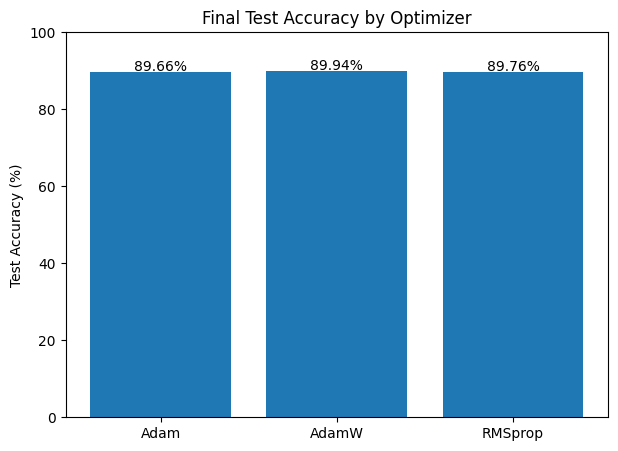

In [15]:
plt.figure(figsize=(7,5))
bars = plt.bar(comparison_df["Optimizer"], comparison_df["Test Acc"])
for bar, acc in zip(bars, comparison_df["Test Acc"]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f"{acc:.2f}%", ha="center")
plt.title("Final Test Accuracy by Optimizer")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)
plt.show()

## Loss and Accuracy Curves (all three together)

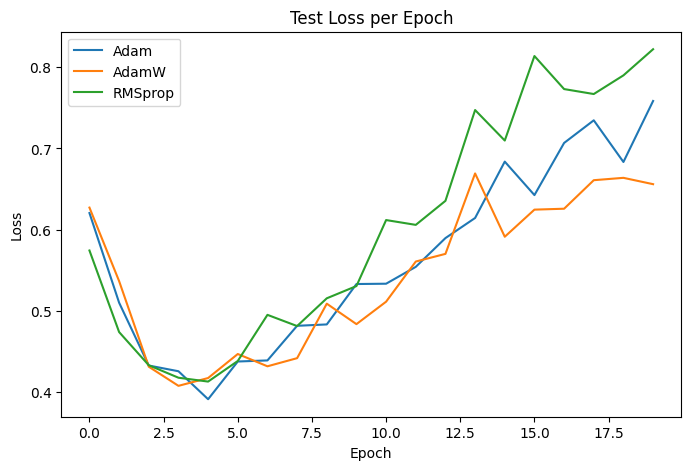

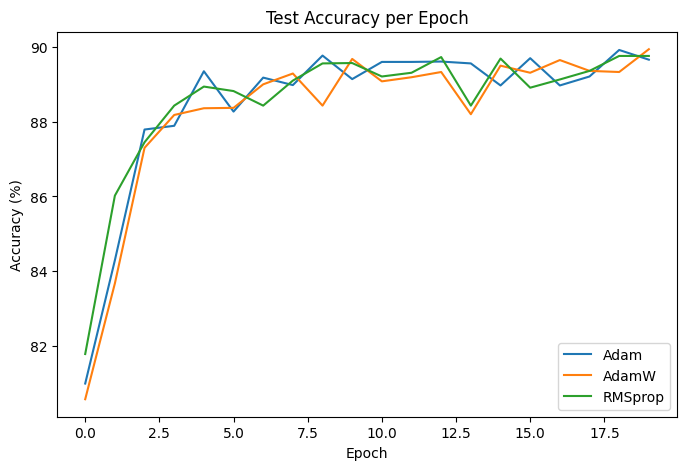

In [16]:
# Test loss per epoch
plt.figure(figsize=(8,5))
plt.plot(adam_history["test_loss"], label="Adam")
plt.plot(adamw_history["test_loss"], label="AdamW")
plt.plot(rmsprop_history["test_loss"], label="RMSprop")
plt.title("Test Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Test accuracy per epoch
plt.figure(figsize=(8,5))
plt.plot(adam_history["test_acc"], label="Adam")
plt.plot(adamw_history["test_acc"], label="AdamW")
plt.plot(rmsprop_history["test_acc"], label="RMSprop")
plt.title("Test Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

## Cross-Validation Accuracy Distribution (best config of each optimizer)

/tmp/ipykernel_708/1045577636.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([adam_best_folds, adamw_best_folds, rmsprop_best_folds],


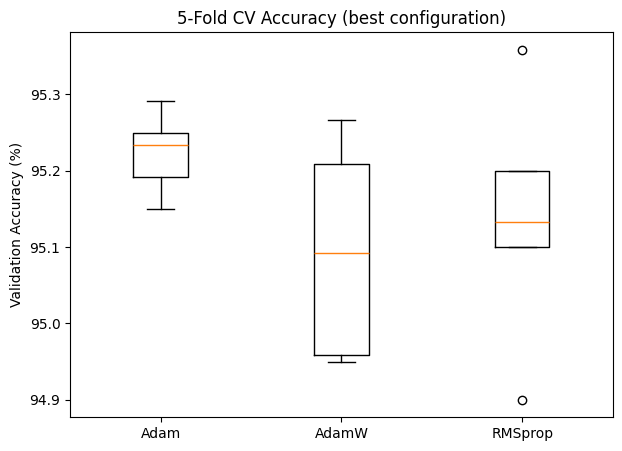

In [17]:
plt.figure(figsize=(7,5))
plt.boxplot([adam_best_folds, adamw_best_folds, rmsprop_best_folds],
            labels=["Adam", "AdamW", "RMSprop"])
plt.title("5-Fold CV Accuracy (best configuration)")
plt.ylabel("Validation Accuracy (%)")
plt.show()

# Part 5 - Discussion, Conclusion & References (by Isha)

### Methodology (short)
All three optimizers shared the **same network, seed (42) and 20 epochs**. Each one tested
at least 4 hyperparameter settings, used **5-fold cross validation** to choose the best, then
trained a final model and tested it on the held-out test set.

### Discussion
- **Convergence:** all three reached high accuracy quickly on KMNIST; check the *Epoch to 80%* column.
- **Learning rate:** very large rates (like 0.1) were unstable for all optimizers; ~0.001 worked best.
- **Generalization gap:** compare *Train Acc* vs *Test Acc* in the table - AdamW's weight decay aims to keep this gap small.
- **Best optimizer:** the one with the highest *Test Acc* / *CV Mean Acc* in the comparison table is our pick for KMNIST.

### When to use each (in general)
- **Adam:** strong default for most tasks.
- **AdamW:** when regularization matters (bigger models, overfitting risk).
- **RMSprop:** noisy or non-stationary problems, RNNs.

### Limitations
1. Only a simple feedforward network (no CNN), so accuracy is capped.
2. Small hyperparameter search (4-5 settings each).

### Future Work
Try a CNN, a wider search, and a learning-rate scheduler.

### Individual Contributions
- **Ruchi:** Adam optimizer experiments.
- **Dilkhush:** AdamW optimizer experiments.
- **Krutik:** RMSprop optimizer experiments.
- **Isha:** Team lead - merged the code into a shared pipeline, wrote documentation and comparison.

### References (APA)
- Kingma, D. P., & Ba, J. (2015). *Adam: A method for stochastic optimization.* ICLR 2015.
- Loshchilov, I., & Hutter, F. (2019). *Decoupled weight decay regularization.* ICLR 2019.
- Tieleman, T., & Hinton, G. (2012). *Lecture 6.5 - RMSProp.* Coursera.
- Clanuwat, T., et al. (2018). *Deep learning for classical Japanese literature.* NeurIPS 2018 Workshop.